In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score 
from sklearn.metrics import ConfusionMatrixDisplay 


In [3]:
matches = pd.read_csv('../data/processed/features_v2.csv')

In [7]:
matches['GoalDiffLast5'] = matches['HomeGoalsLast5'] - matches['AwayGoalsLast5'] 
matches['PointsDiffLast5'] = matches['HomePointsLast5'] - matches['AwayPointsLast5'] 
matches['GoalAgainstDiffLast5'] = matches['AwayGoalsAgainstLast5'] - matches['HomeGoalsAgainstLast5'] 
matches['ShotDiffLast5'] = matches['HomeShotsForLast5'] - matches['AwayShotsForLast5'] 
matches['ShotOTDiffLast5'] = matches['HomeShotsOnTargetLast5'] - matches['AwayShotsOnTargetLast5']

C:\Users\harry\AppData\Local\Temp\ipykernel_42772\2143085457.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matches['GoalDiffLast5'] = matches['HomeGoalsLast5'] - matches['AwayGoalsLast5']
C:\Users\harry\AppData\Local\Temp\ipykernel_42772\2143085457.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matches['PointsDiffLast5'] = matches['HomePointsLast5'] - matches['AwayPointsLast5']
C:\Users\harry\AppData\Local\Temp\ipykernel_42772\2143085457.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the re

In [8]:
features = [ 'GoalDiffLast5', 'PointsDiffLast5', 'GoalAgainstDiffLast5', 'ShotOTDiffLast5', 'PPGDiff', 'GDPerGameDiff', 'GoalsPerGameDiff', 'GoalsAgainstPerGameDiff' ]

In [9]:
train = matches[matches['Season'] != '25-26'] 
test = matches[matches['Season'] == '25-26']

In [10]:
X_train = train[features] 
y_train = train['FTR'] 
X_test = test[features] 
y_test = test['FTR']

In [21]:
 
model = LogisticRegression(
    max_iter=1000,
)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [22]:
preds = model.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, preds) 
print(accuracy)

0.4789473684210526


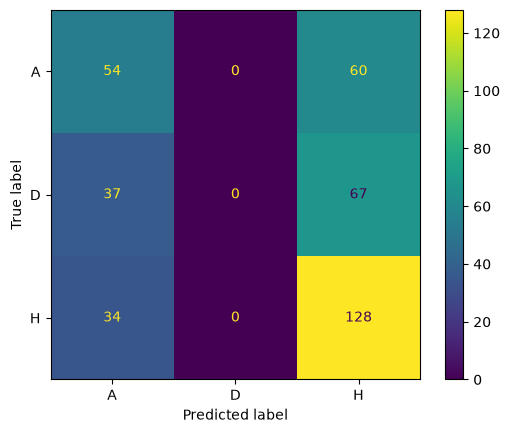

In [25]:
ConfusionMatrixDisplay.from_predictions(y_test, preds)

In [26]:
probs = model.predict_proba(X_test) 
print(model.classes_) 
print(probs[0])

['A' 'D' 'H']
[0.30253241 0.22716662 0.47030096]


In [27]:
results = test[['HomeTeam', 'AwayTeam', 'FTR']].copy() 
results['Predicted'] = preds 
results['AwayProb'] = probs[:, 0] 
results['DrawProb'] = probs[:, 1] 
results['HomeProb'] = probs[:, 2] 
results.head(10)

,HomeTeam,AwayTeam,FTR,Predicted,AwayProb,DrawProb,HomeProb
1520,Liverpool,Bournemouth,H,H,0.302532,0.227167,0.470301
1521,Aston Villa,Newcastle,D,H,0.341900,0.306085,0.352015
1522,Brighton,Fulham,D,H,0.264795,0.225861,0.509343
1523,Sunderland,West Ham,H,H,0.331330,0.258530,0.410140
1524,Tottenham,Burnley,H,A,0.376740,0.327861,0.295399
1525,Wolves,Man City,A,H,0.343785,0.248480,0.407735
1526,Chelsea,Crystal Palace,D,H,0.316819,0.292622,0.390558
1527,Nott'm Forest,Brentford,H,H,0.318532,0.252264,0.429203
1528,Man United,Arsenal,A,H,0.309474,0.241023,0.449503
1529,Leeds,Everton,H,A,0.380614,0.286155,0.333231


In [28]:
importance = pd.Series( model.coef_[2], index=features ).sort_values(ascending=False) 
print(importance)

PPGDiff                    0.292202
GoalAgainstDiffLast5       0.150430
ShotOTDiffLast5            0.108456
GDPerGameDiff              0.070861
GoalsAgainstPerGameDiff    0.039956
GoalsPerGameDiff           0.030906
GoalDiffLast5             -0.010053
PointsDiffLast5           -0.016718
dtype: float64


In [29]:
from sklearn.metrics import log_loss 
print(log_loss(y_test, probs))

1.0492356340651103


In [30]:
probs = model.predict_proba(X_test) 
results['DrawProb'] = probs[:, list(model.classes_).index('D')] 
results.sort_values('DrawProb', ascending=False).head(20)

,HomeTeam,AwayTeam,FTR,Predicted,AwayProb,DrawProb,HomeProb
1524,Tottenham,Burnley,H,A,0.376740,0.327861,0.295399
1763,Bournemouth,Aston Villa,D,A,0.427664,0.323235,0.249101
1521,Aston Villa,Newcastle,D,H,0.341900,0.306085,0.352015
1828,Tottenham,Nott'm Forest,A,H,0.323909,0.300340,0.375751
1532,Bournemouth,Wolves,H,H,0.166514,0.299879,0.533607
1867,Chelsea,Nott'm Forest,A,H,0.307828,0.299879,0.392293
1856,Wolves,Tottenham,A,A,0.446050,0.299431,0.254519
1720,West Ham,Nott'm Forest,A,A,0.381586,0.299216,0.319198
1644,Tottenham,Fulham,A,H,0.274524,0.298251,0.427225
1876,Crystal Palace,Everton,D,A,0.358224,0.297748,0.344028
